<a href="https://colab.research.google.com/github/lilianabs/kaggle-tools/blob/main/Signals_features_and_categorical_target.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt


np.random.seed(42)
n = 1000

# Target (binary classification)
y = np.random.binomial(1, 0.5, n)

# Feature 1: Strong signal
f1 = np.where(y == 0,
              np.random.normal(10, 2, n),
              np.random.normal(20, 2, n))

# Feature 2: Medium signal
f2 = np.where(y == 0,
              np.random.normal(10, 5, n),
              np.random.normal(15, 5, n))

# Feature 3: Weak signal
f3 = np.where(y == 0,
              np.random.normal(10, 5, n),
              np.random.normal(11, 5, n))

# Feature 4: No signal
f4 = np.random.normal(10, 5, n)

df = pd.DataFrame({
    "target": y,
    "f1": f1,
    "f2": f2,
    "f3": f3,
    "f4": f4
})

In [2]:
df.head()

,target,f1,f2,f3,f4
0,0,10.355402,14.372585,11.395419,16.009658
1,1,19.833789,13.366519,7.577541,10.043942
2,1,16.990559,9.787112,13.286621,10.289320
3,1,21.520112,9.138831,21.491107,8.672037
4,0,11.119581,7.563985,23.776089,13.422252


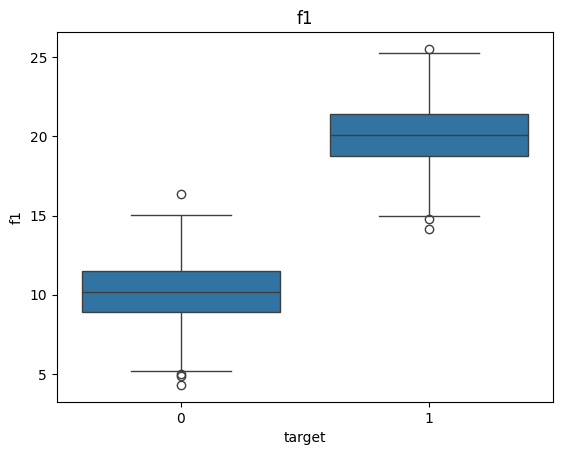

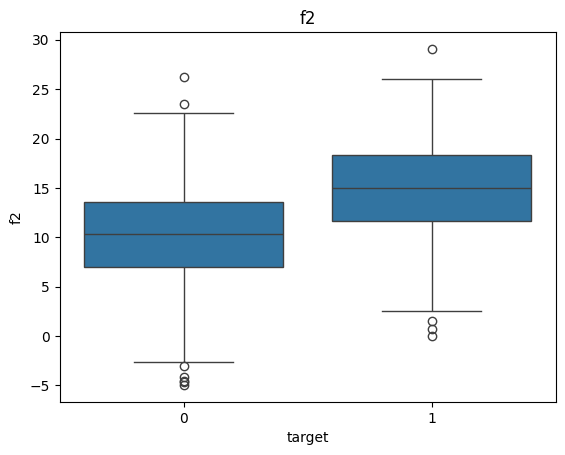

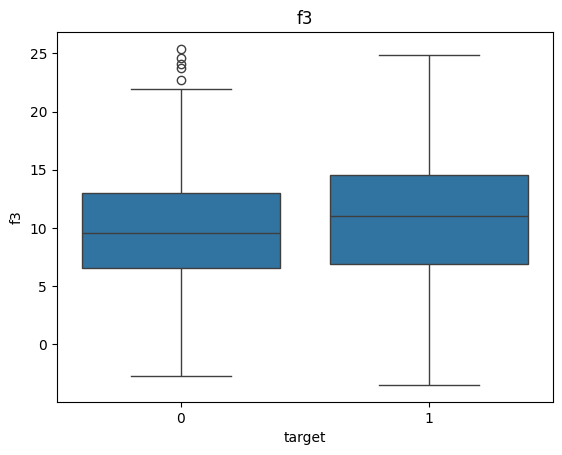

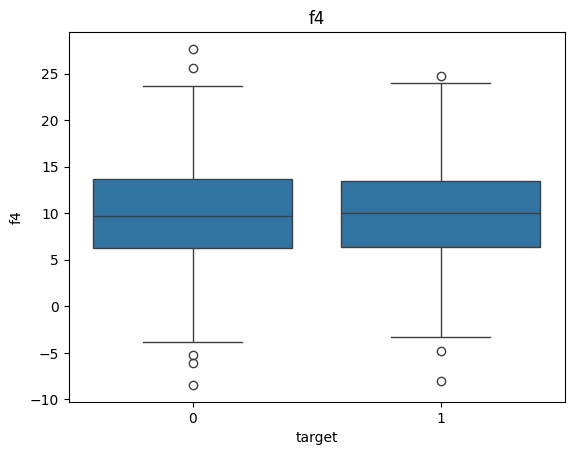

In [4]:
for col in ["f1", "f2", "f3", "f4"]:
    sns.boxplot(x="target", y=col, data=df)
    plt.title(col)
    plt.show()

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

results = []

for col in ["f1", "f2", "f3", "f4"]:
    model = LogisticRegression()
    X = df[[col]]
    model.fit(X, df["target"])

    preds = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(df["target"], preds)

    results.append((col, auc))

results

[('f1', np.float64(0.9999079966878808)),
 ('f2', np.float64(0.7443787976367149)),
 ('f3', np.float64(0.5613242076714762)),
 ('f4', np.float64(0.5071062558252097))]

**Strong signal**
 - Clear separation
 - Almost no overlap
 - High AUC (~0.9+)

**Medium signal**
 - Some separation
 - Noticeable overlap
 - AUC (~0.7–0.8)

**Weak signal**
 - Heavy overlap
 - Slight median shift
 - AUC (~0.55–0.65)

**No signal**
 - Completely overlapping
 - AUC (~0.5)

In [6]:
df["f5"] = np.random.normal(0, 10, len(df))
df["f6"] = np.random.uniform(-1, 1, len(df))

In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
X = df.drop(columns=["target"])
model.fit(X, df["target"])

importances = model.feature_importances_
list(zip(X.columns, importances))

[('f1', np.float64(0.8353774375388525)),
 ('f2', np.float64(0.0969454495394394)),
 ('f3', np.float64(0.02384212529243515)),
 ('f4', np.float64(0.014031490528174798)),
 ('f5', np.float64(0.012771580503912727)),
 ('f6', np.float64(0.017031916597185535))]

👉 Observe:

 - Weak features still contribute
 - Strong features dominate

# Categorical variables

What “strong vs weak signal” looks like

Let’s build intuition with a simple example.

✅ Strong signal

Interpretation:

 - If feature = A → almost always class 0
 - If feature = B → almost always class 1

👉 This is like a perfect split in a decision tree

⚠️ Medium signal

Interpretation:

 - A leans toward class 0
 - B leans toward class 1

👉 Useful, but not decisive

❌ No signal

Interpretation:

 - Feature gives zero information about target

In [8]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 1000

# Binary target
y = np.random.binomial(1, 0.5, n)

# Strong signal feature
f1 = np.where(y == 0,
              np.random.choice(["A", "B"], size=n, p=[0.9, 0.1]),
              np.random.choice(["A", "B"], size=n, p=[0.1, 0.9]))

# Medium signal feature
f2 = np.where(y == 0,
              np.random.choice(["A", "B"], size=n, p=[0.7, 0.3]),
              np.random.choice(["A", "B"], size=n, p=[0.3, 0.7]))

# Weak signal feature
f3 = np.where(y == 0,
              np.random.choice(["A", "B"], size=n, p=[0.55, 0.45]),
              np.random.choice(["A", "B"], size=n, p=[0.45, 0.55]))

# No signal feature
f4 = np.random.choice(["A", "B"], size=n)

df = pd.DataFrame({
    "target": y,
    "f1": f1,
    "f2": f2,
    "f3": f3,
    "f4": f4
})

In [9]:
df.head()

,target,f1,f2,f3,f4
0,0,A,A,A,A
1,1,B,B,A,A
2,1,B,B,B,A
3,1,B,A,B,A
4,0,A,A,B,A


In [11]:
features = ["f1", "f2", "f3", "f4"]
for feat in features:
  print(f"Feature {feat}")
  display(pd.crosstab(df[feat], df["target"], normalize="index"))
  print("***********************************************")

Feature f1


target,0,1
f1,,
A,0.906188,0.093812
B,0.098196,0.901804


***********************************************
Feature f2


target,0,1
f2,,
A,0.725806,0.274194
B,0.283730,0.716270


***********************************************
Feature f3


target,0,1
f3,,
A,0.540206,0.459794
B,0.467961,0.532039


***********************************************
Feature f4


target,0,1
f4,,
A,0.522472,0.477528
B,0.480687,0.519313


***********************************************


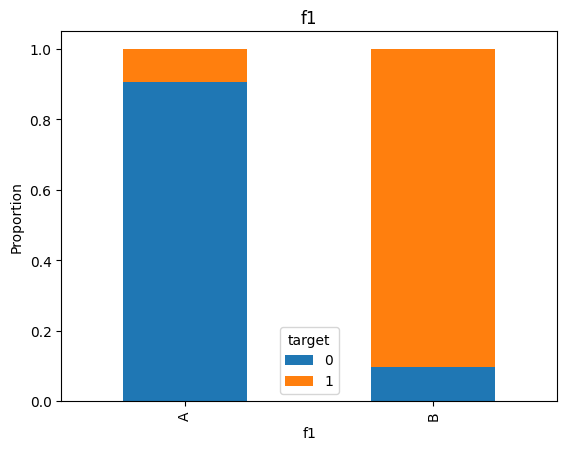

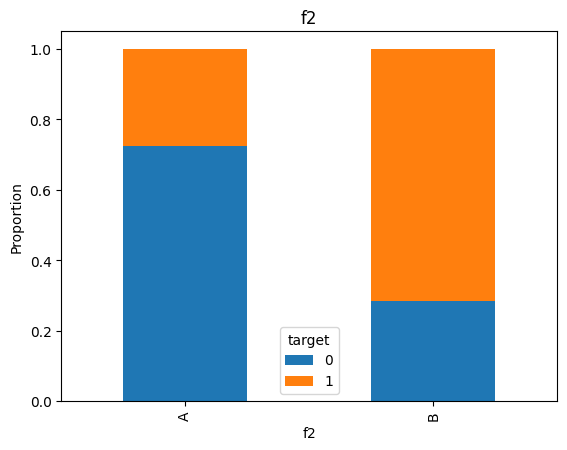

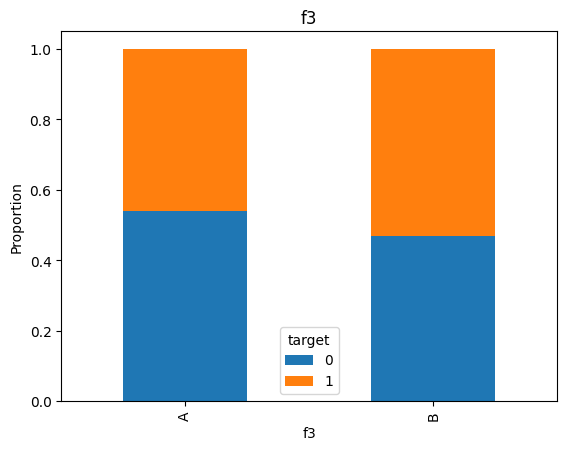

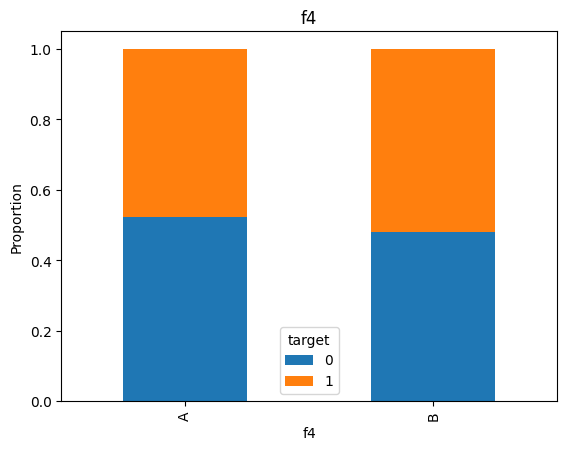

In [12]:
import matplotlib.pyplot as plt

for col in ["f1", "f2", "f3", "f4"]:
    pd.crosstab(df[col], df["target"], normalize="index") \
      .plot(kind="bar", stacked=True)

    plt.title(col)
    plt.ylabel("Proportion")
    plt.show()

In [13]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

results = []

for col in ["f1", "f2", "f3", "f4"]:
    enc = OneHotEncoder(drop="first", sparse_output=False)
    X = enc.fit_transform(df[[col]])

    model = LogisticRegression()
    model.fit(X, df["target"])

    preds = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(df["target"], preds)

    results.append((col, auc))

results

[('f1', np.float64(0.904008544307595)),
 ('f2', np.float64(0.7210319571504574)),
 ('f3', np.float64(0.5360912992867743)),
 ('f4', np.float64(0.5207967486829526))]

**Strong signal**
 - Big difference in proportions (e.g., 90% vs 10%)
 - AUC ~ 0.85+

**Medium signal**
 - Noticeable shift (e.g., 70% vs 30%)
 - AUC ~ 0.65–0.75

**Weak signal**
 - Slight shift (e.g., 55% vs 45%)
 - AUC ~ 0.52–0.60

**No signal**
 - Same proportions
 - AUC ~ 0.5